# AC 209b / CS 1090b MS4 Main Notebook - Project 66

**Team:** Harry Hu, Tom Shan, Wendy Wang, Kemeng Zhang

This notebook tells the final modeling story for our Reddit MBTI project. The central question is simple: can a user's Reddit writing predict their MBTI dimensions, and do text-derived emotion representations add useful author-level signal beyond strong text representations?

The final answer is nuanced. The most reliable improvement comes from modeling each user as an author with many posts, not from treating posts as independent personality examples. Emotion features are informative enough to study, but the strongest evidence supports them as suggestive transferred representations rather than a stable standalone driver of performance.


## Notebook Setup

The notebook reads compact, tracked report artifacts from `report/results/`. Expensive preprocessing, embedding caches, and training outputs live under `code/artifacts/` and are not required for normal notebook review.


In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

CODE_DIR = Path.cwd()
MS4_DIR = CODE_DIR.parent
SRC_DIR = CODE_DIR / "src"
REPORT_RESULTS_DIR = MS4_DIR / "report" / "results"
ARTIFACT_DIR = CODE_DIR / "artifacts"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_colwidth", 120)

def show_png(filename: str):
    display(Image(filename=str(REPORT_RESULTS_DIR / filename)))


This is a results notebook rather than a training log. It loads compact tables and figures from `report/results/`; large caches and checkpoints are excluded from the submitted artifacts.


## 1. Scientific Framing

The prediction unit is the **author**, not the individual post. Each author has one self-reported MBTI label, while individual posts only inherit that label noisily. Treating posts as independent personality examples would make the task look cleaner than it really is.

For that reason, all headline results are evaluated at the author level with author-level train/validation/test splits, validation-tuned thresholds, and balanced accuracy. The emotion features are also interpreted carefully: they are text-derived representations from an emotion classifier, not independent measurements of a user's true emotional state.

The key emotion comparison is therefore matched and controlled: compare `text + real emotion` against `text-only`, then check whether `text + shuffled emotion` gives the same kind of improvement. If shuffled emotion performs just as well, the result is not strong evidence for author-aligned emotion signal.


## 2. Data and Preprocessing Checks

Before modeling, we mask direct MBTI leakage, filter very short posts, keep authors with enough retained posts, cap each author at 200 posts, and split by author. These checks make sure the final scores reflect generalization to held-out users rather than memorizing obvious type strings or author identity.


In [2]:
pre_dir = ARTIFACT_DIR / "preprocessed" / "full"
summary_path = pre_dir / "summary.json"
leakage_path = pre_dir / "mbti_leakage_audit.csv"
split_balance_path = pre_dir / "split_balance.csv"

preprocess_summary = json.loads(summary_path.read_text()) if summary_path.exists() else {}
summary_keep = [
    "n_modeling_authors",
    "n_modeling_posts",
    "train_authors",
    "val_authors",
    "test_authors",
    "max_posts_per_author",
]
summary_table = pd.DataFrame([
    {key: preprocess_summary.get(key) for key in summary_keep if key in preprocess_summary}
])
display(summary_table)

if leakage_path.exists():
    display(pd.read_csv(leakage_path))
if split_balance_path.exists():
    split_balance = pd.read_csv(split_balance_path)
    display(split_balance)


,n_modeling_authors,n_modeling_posts
0,10414,1649102


,stage,n_posts,n_authors,posts_with_any_term,post_share_with_any_term,authors_with_any_term,author_share_with_any_term,posts_with_own_type,post_share_with_own_type
0,before_masking,13028455,11773,216846,0.016644,9232,0.784167,112294,0.008619
1,after_masking,13028455,11773,0,0.000000,0,0.000000,0,0.000000


,split,target,n_authors,positive_share,positive_count,negative_count
0,test,target_E,1563,0.213692,334,1229
1,test,target_S,1563,0.067179,105,1458
2,test,target_T,1563,0.397313,621,942
3,test,target_J,1563,0.397313,621,942
4,train,target_E,7289,0.213472,1556,5733
5,train,target_S,7289,0.068322,498,6791
6,train,target_T,7289,0.397585,2898,4391
7,train,target_J,7289,0.397037,2894,4395
8,val,target_E,1562,0.213188,333,1229
9,val,target_S,1562,0.069142,108,1454


The main safeguard is the author-level split: a user appears in train, validation, or test, never more than one. The leakage audit also checks that explicit MBTI strings are masked before modeling.


## 3. Why Post Budget Matters

A single Reddit post is a weak and noisy view of personality. We therefore audit truncation and compare model behavior under different retained-post budgets. This becomes central later: the strongest transformer model uses up to 200 posts per author.


,max_length,n_posts,n_authors,median_tokens,p90_tokens,p95_tokens,p99_tokens,share_posts_over_max,share_authors_with_any_truncation
0,128,1649102,10414,22.0,97.0,147.0,295.0,6.37%,90.42%
1,256,1649102,10414,22.0,97.0,147.0,295.0,1.46%,59.62%


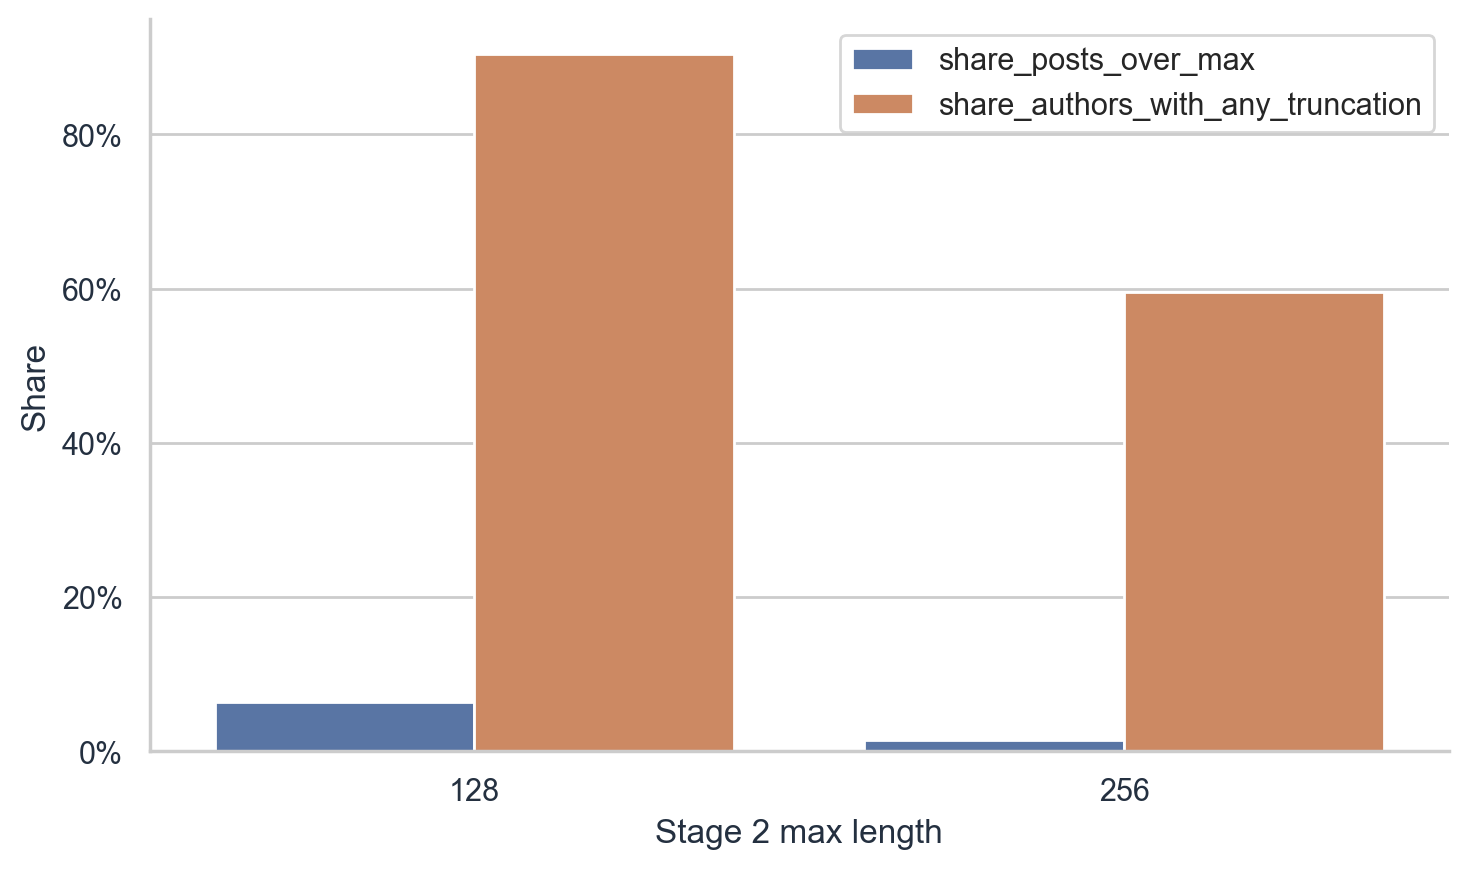

,max_length,run_id,epochs_completed,best_val_loss,final_train_loss,test_mean_balanced_accuracy,test_mean_f1,parameter_count
0,128,stage2_text_gru_full,4,0.7200,0.7007,0.5964,0.4225,3947588
1,256,stage2_text_gru_len256_full,3,0.7262,0.7209,0.5029,0.0925,3947588


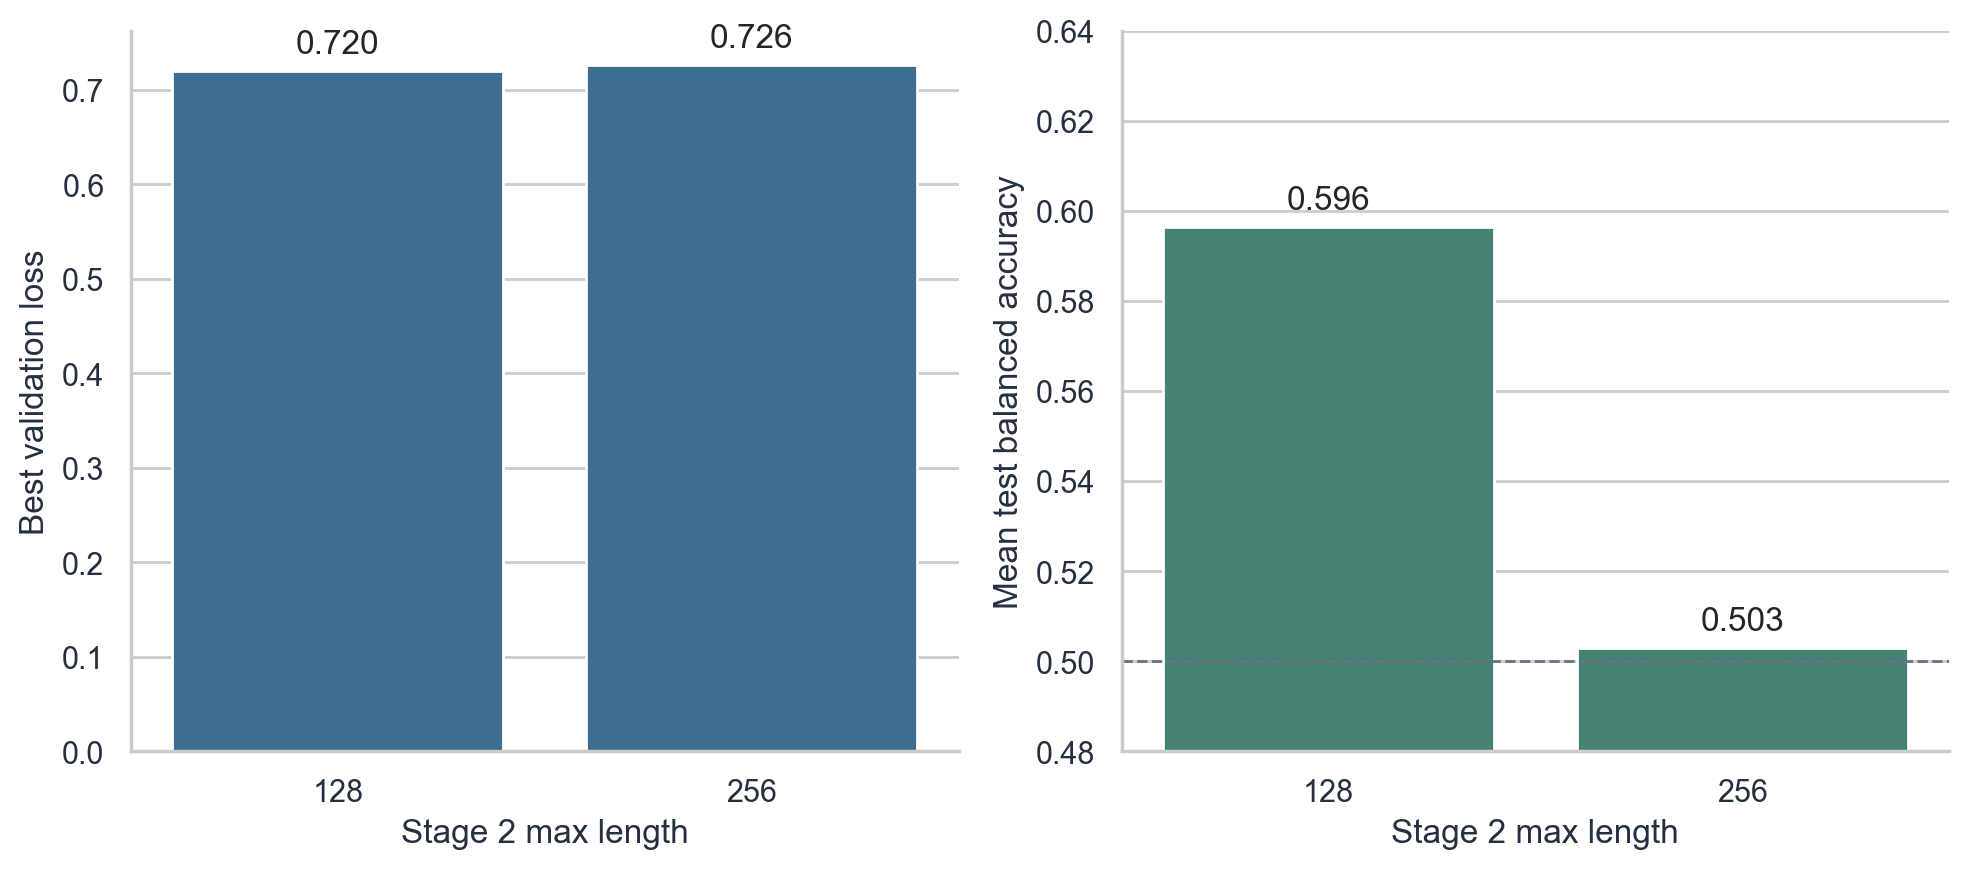

In [3]:
token_length_sensitivity = pd.read_csv(REPORT_RESULTS_DIR / "token_length_sensitivity.csv")
max_length_training_sensitivity = pd.read_csv(REPORT_RESULTS_DIR / "max_length_training_sensitivity.csv")

display(token_length_sensitivity.style.format({
    "median_tokens": "{:.1f}",
    "p90_tokens": "{:.1f}",
    "p95_tokens": "{:.1f}",
    "p99_tokens": "{:.1f}",
    "share_posts_over_max": "{:.2%}",
    "share_authors_with_any_truncation": "{:.2%}",
}))
show_png("fig_token_length_sensitivity.png")

display(max_length_training_sensitivity.style.format({
    "best_val_loss": "{:.4f}",
    "final_train_loss": "{:.4f}",
    "test_mean_balanced_accuracy": "{:.4f}",
    "test_mean_f1": "{:.4f}",
}))
show_png("fig_max_length_training_sensitivity.png")


The length audit shows that truncation is real, but simply extending the GRU input length does not solve the problem. This motivates representing an author with many post embeddings instead of relying on a single sequence model.


## 4. Baseline Layer: What Did the Older Models Show?

The baseline layer includes majority prediction, TF-IDF logistic regression, and corrected GRU models. These are important because they set the floor: any new transformer approach should beat both the trivial imbalance baseline and a strong lexical author baseline.


,model_id,model_name,balanced_accuracy,f1,minority_recall,roc_auc,average_precision
0,linear_tfidf_author,TF-IDF Logistic,0.6512,0.4609,0.5904,0.7100,0.4643
1,stage2_text_emotion_gru,GRU Text + Emotion,0.6223,0.4336,0.5904,0.6833,0.4451
2,stage2_text_gru_sqrt,GRU Text,0.5964,0.4225,0.6318,0.6591,0.4132
3,stage2_text_gru_inverse,GRU Text Inverse Weight,0.5855,0.3972,0.5546,0.6265,0.3821
4,majority_author,Majority,0.5000,0.0000,0.0000,0.5000,0.2689


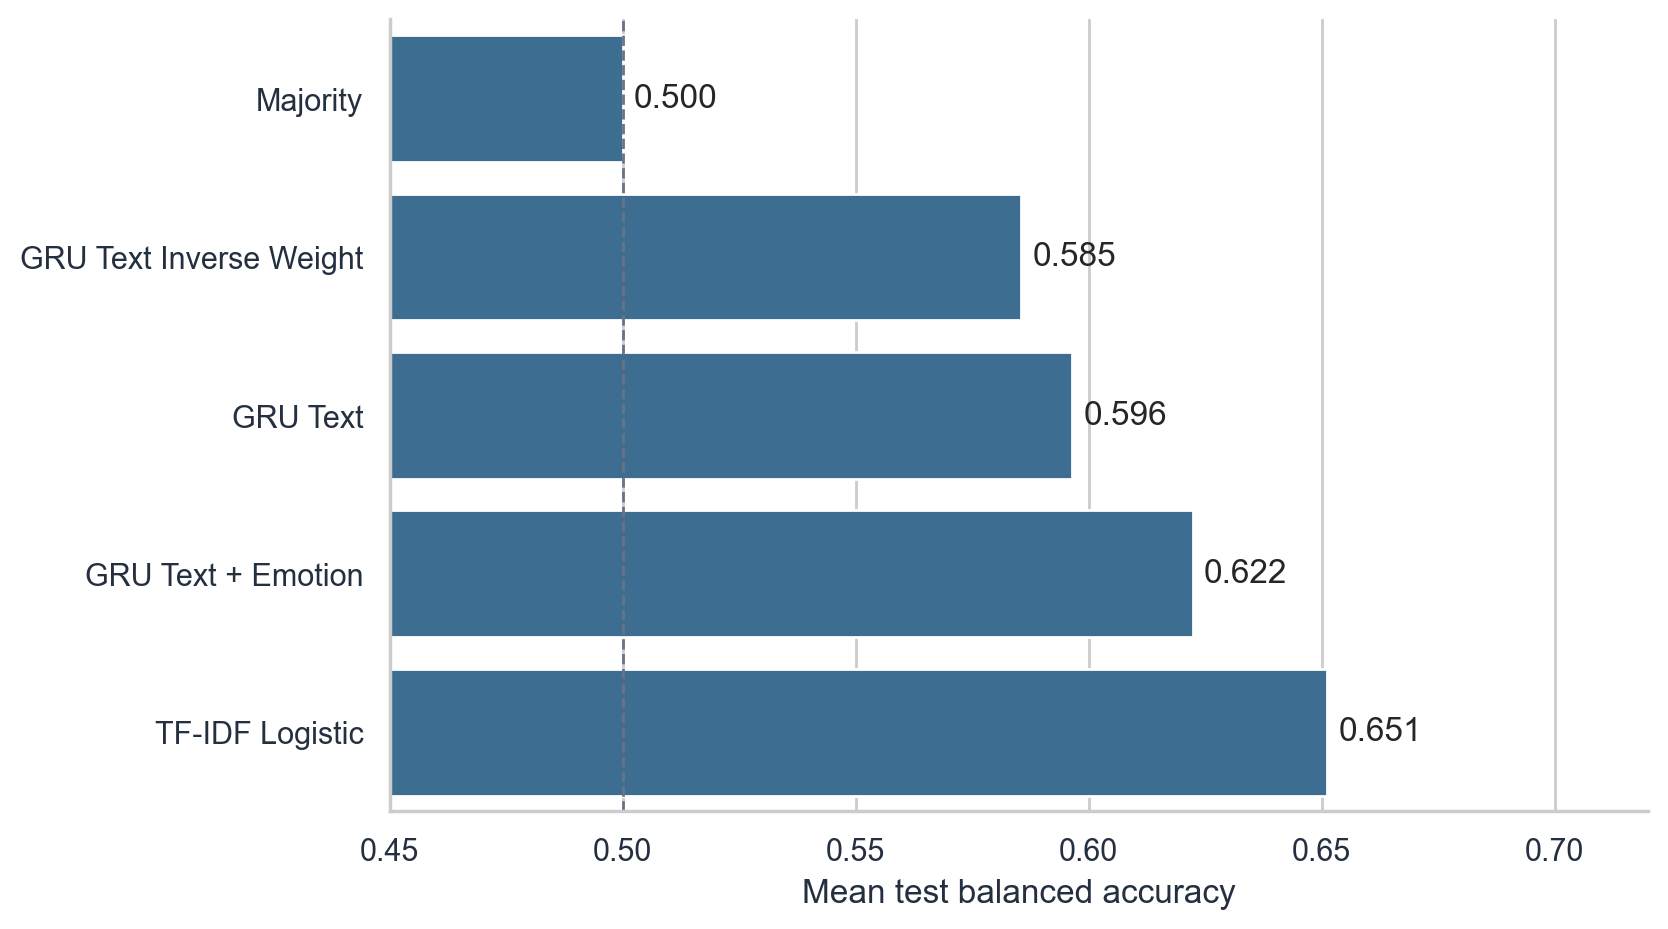

In [4]:
model_summary = pd.read_csv(REPORT_RESULTS_DIR / "model_summary.csv")
display(model_summary.style.format({
    "balanced_accuracy": "{:.4f}",
    "f1": "{:.4f}",
    "minority_recall": "{:.4f}",
    "roc_auc": "{:.4f}",
    "average_precision": "{:.4f}",
}))
show_png("fig_model_summary_balanced_accuracy.png")


The corrected GRU plus emotion improves over corrected GRU text-only, but TF-IDF logistic regression remains stronger. That makes the baseline result useful but not sufficient: the final model needs to match the author-level structure of the task, not just add neural complexity.


## 5. Per-Dimension Performance

MBTI dimensions are not equally difficult. Looking only at an average can hide whether a model improves broadly or only on one dimension.


,model_name,target,balanced_accuracy,f1,minority_recall,roc_auc,average_precision
12,TF-IDF Logistic,target_E,0.6694,0.4675,0.6138,0.7331,0.4312
36,GRU Text + Emotion,target_E,0.6119,0.4004,0.5599,0.6777,0.3831
20,GRU Text,target_E,0.5958,0.3795,0.5000,0.6528,0.3427
28,GRU Text Inverse Weight,target_E,0.5890,0.3764,0.5449,0.6325,0.3190
4,Majority,target_E,0.5000,0.0000,0.0000,0.5000,0.2137
15,TF-IDF Logistic,target_J,0.6271,0.5381,0.5121,0.6845,0.5941
39,GRU Text + Emotion,target_J,0.6191,0.5484,0.5652,0.6680,0.5842
23,GRU Text,target_J,0.5656,0.5498,0.7150,0.6095,0.5056
31,GRU Text Inverse Weight,target_J,0.5606,0.4587,0.4428,0.5850,0.4731
7,Majority,target_J,0.5000,0.0000,0.0000,0.5000,0.3973


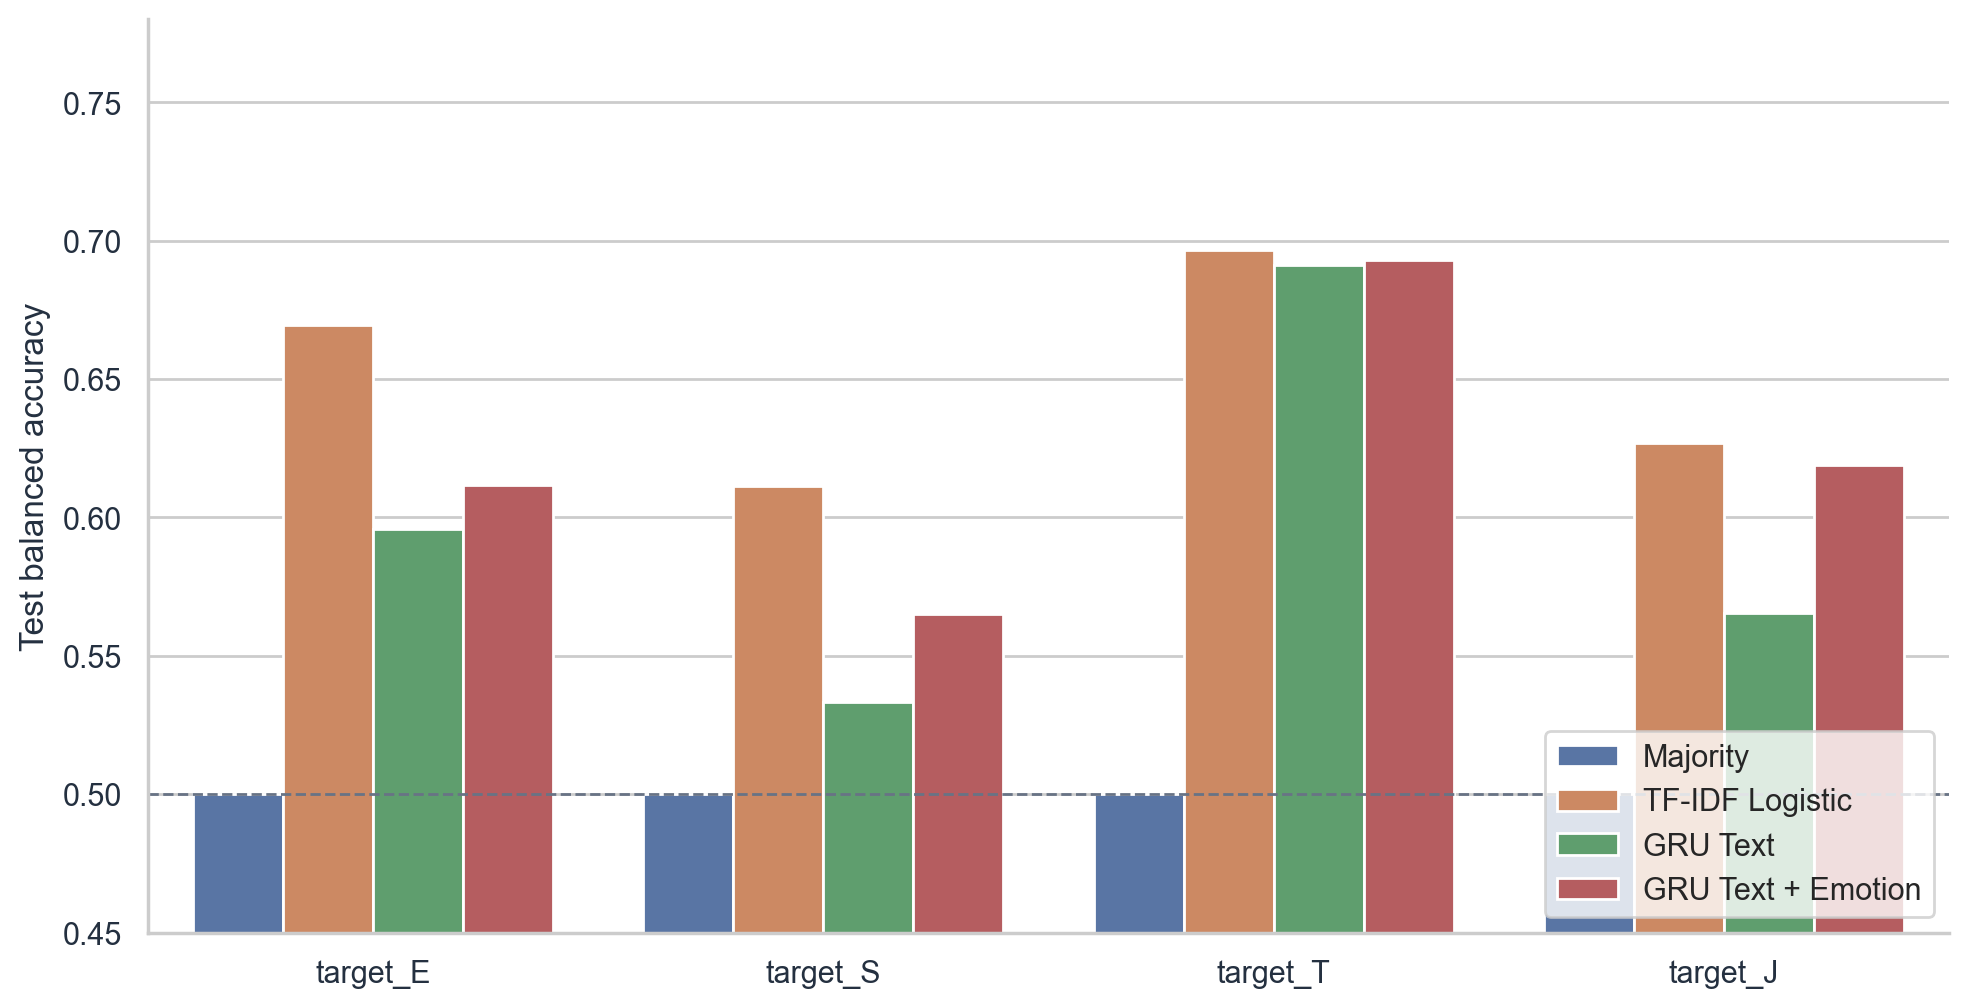

In [5]:
all_metrics = pd.read_csv(REPORT_RESULTS_DIR / "all_model_metrics.csv")
test_metrics = all_metrics.loc[all_metrics["split"] == "test"].copy()
cols = ["model_name", "target", "balanced_accuracy", "f1", "minority_recall", "roc_auc", "average_precision"]
display(test_metrics[cols].sort_values(["target", "balanced_accuracy"], ascending=[True, False]).style.format({
    "balanced_accuracy": "{:.4f}",
    "f1": "{:.4f}",
    "minority_recall": "{:.4f}",
    "roc_auc": "{:.4f}",
    "average_precision": "{:.4f}",
}))
show_png("fig_target_balanced_accuracy.png")


Performance varies by MBTI dimension, which is why the report should avoid a single undifferentiated accuracy claim. Balanced accuracy is the headline metric because several dimensions are imbalanced.


## 6. What Did Emotion Add in the GRU Baseline?

The first emotion test asks whether DistilBERT emotion probabilities help after fixing class weighting, author aggregation, and threshold tuning for the GRU baseline.


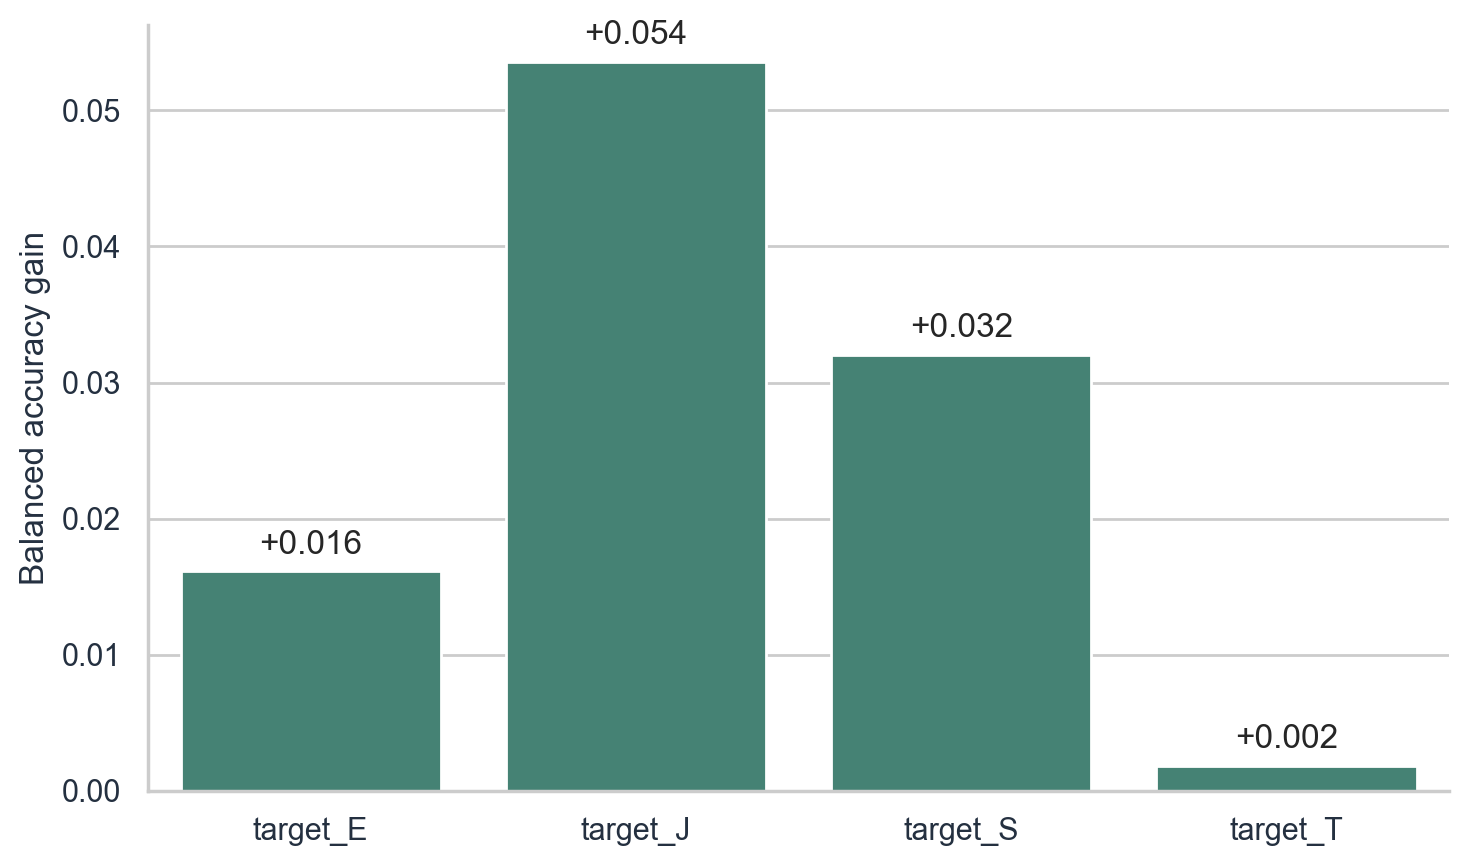

In [6]:
show_png("fig_emotion_gain_by_target.png")


The GRU emotion result is a useful motivation, not the final evidence. Emotion probabilities are derived from the same text, and the GRU is not the strongest model family.


## 7. Emotion Features Are Transferred Across Domains

The emotion model was trained on a source emotion dataset and applied to Reddit posts. The source and target distributions are not identical, so emotion features must be interpreted as transferred text-derived representations.


,source,emotion,share
0,Emotion source labels,sadness,0.167
1,Emotion source labels,joy,0.167
2,Emotion source labels,love,0.167
3,Emotion source labels,anger,0.167
4,Emotion source labels,fear,0.167
5,Emotion source labels,surprise,0.167
6,Reddit inferred,sadness,0.113
7,Reddit inferred,joy,0.496
8,Reddit inferred,love,0.025
9,Reddit inferred,anger,0.274


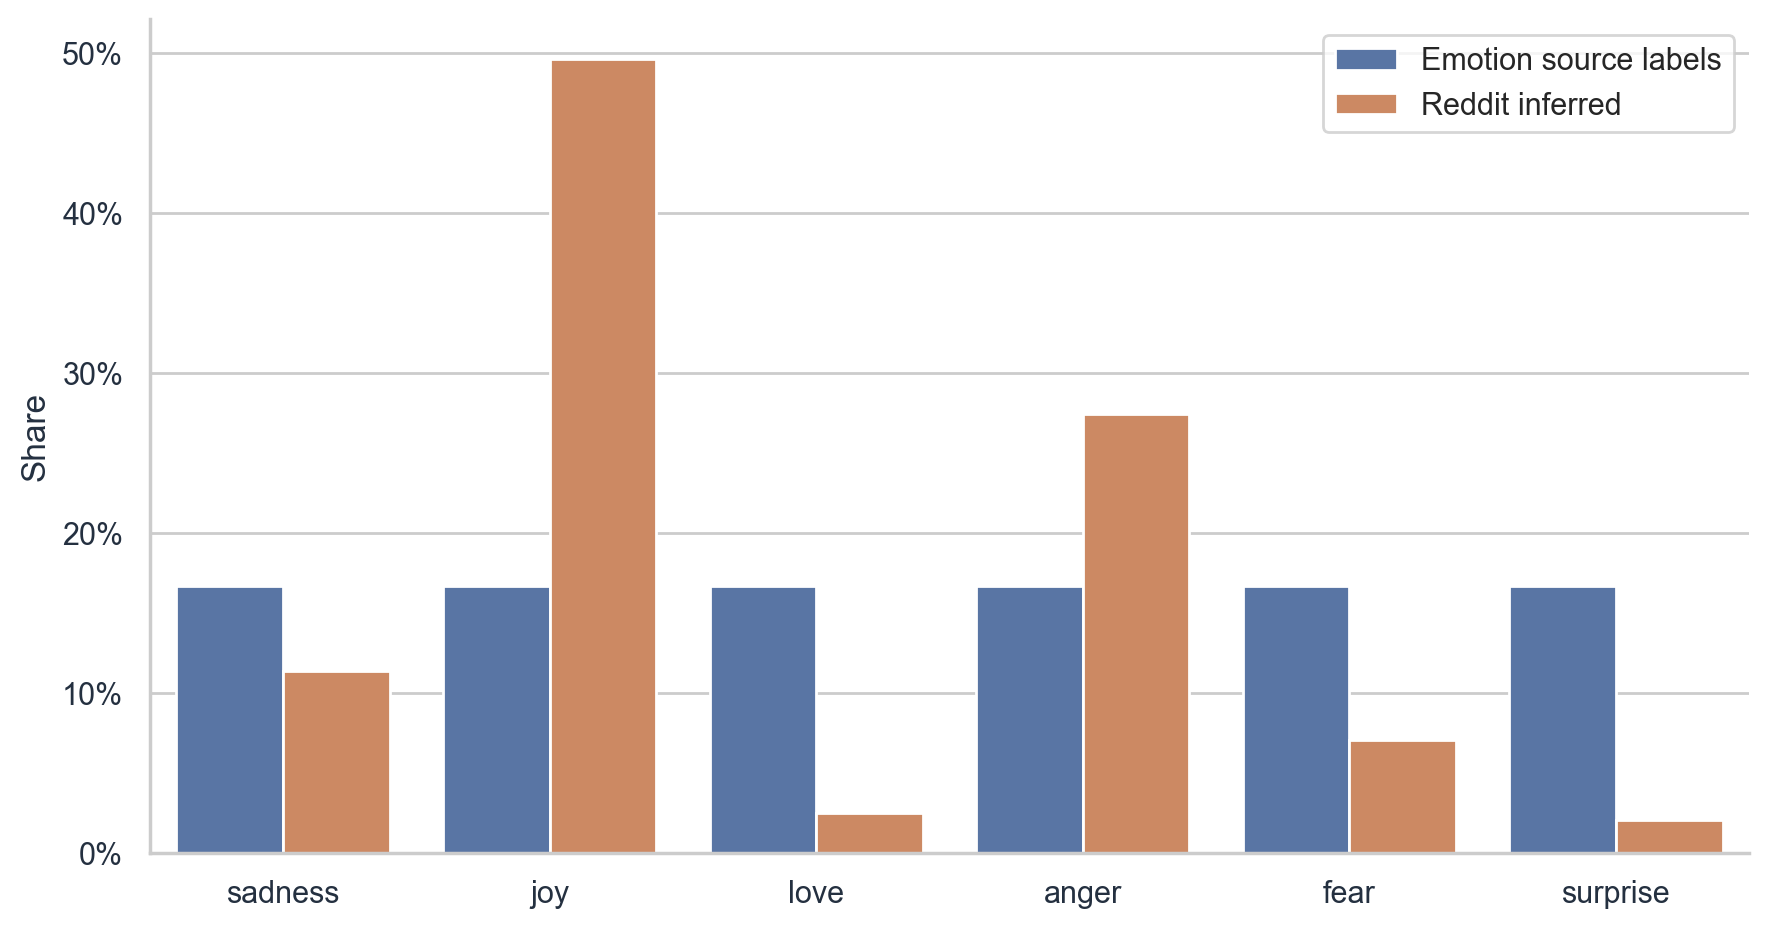

In [7]:
emotion_dist = pd.read_csv(REPORT_RESULTS_DIR / "emotion_distribution_source_vs_reddit.csv")
display(emotion_dist.style.format({"share": "{:.3f}"}))
show_png("fig_source_vs_reddit_emotion_distribution.png")


The source-to-Reddit distribution shift is a reminder to treat emotion probabilities as transferred text features, not as ground-truth measurements of a user's emotional state.


## 8. Main Model Shift: Author-Level Transformer Representations

The updated MS4 direction uses frozen MiniLM post embeddings and author-level models. The frozen-probe path summarizes each author's post embeddings with simple statistics, while the set/attention path lets the model learn how to aggregate a user's unordered set of posts.

The shuffled-emotion variant is the key negative control. It keeps the marginal emotion distribution but breaks the alignment between a user's posts and that user's emotion features. If shuffled emotion performs about as well as real emotion, the result should not be interpreted as strong evidence for author-aligned emotion signal.


## 9. Frozen Transformer Author Probes

First, we freeze MiniLM, summarize each author's post embeddings, and train lightweight author-level classifiers. This tests whether transformer text representations alone are enough to beat the earlier baselines.


,model_id,model_name,balanced_accuracy,f1,minority_recall,roc_auc,average_precision,post_budget
0,frozen_text_mean_std,Frozen Text,0.6293,0.4285,0.5866,0.6747,0.4172,nan
1,frozen_text_real_emotion_controls,Frozen Text + Real Emotion + Controls,0.6289,0.4417,0.5945,0.6742,0.4208,nan
2,frozen_text_shuffled_emotion,Frozen Text + Shuffled Emotion,0.6274,0.4411,0.5999,0.6741,0.4162,nan
3,frozen_text_controls,Frozen Text + Controls,0.6260,0.4442,0.6022,0.6724,0.4190,nan
4,frozen_text_real_emotion,Frozen Text + Real Emotion,0.6233,0.4371,0.5769,0.6738,0.4192,nan
5,frozen_emotion_only,Emotion Only,0.5651,0.3942,0.5639,0.5821,0.3370,nan


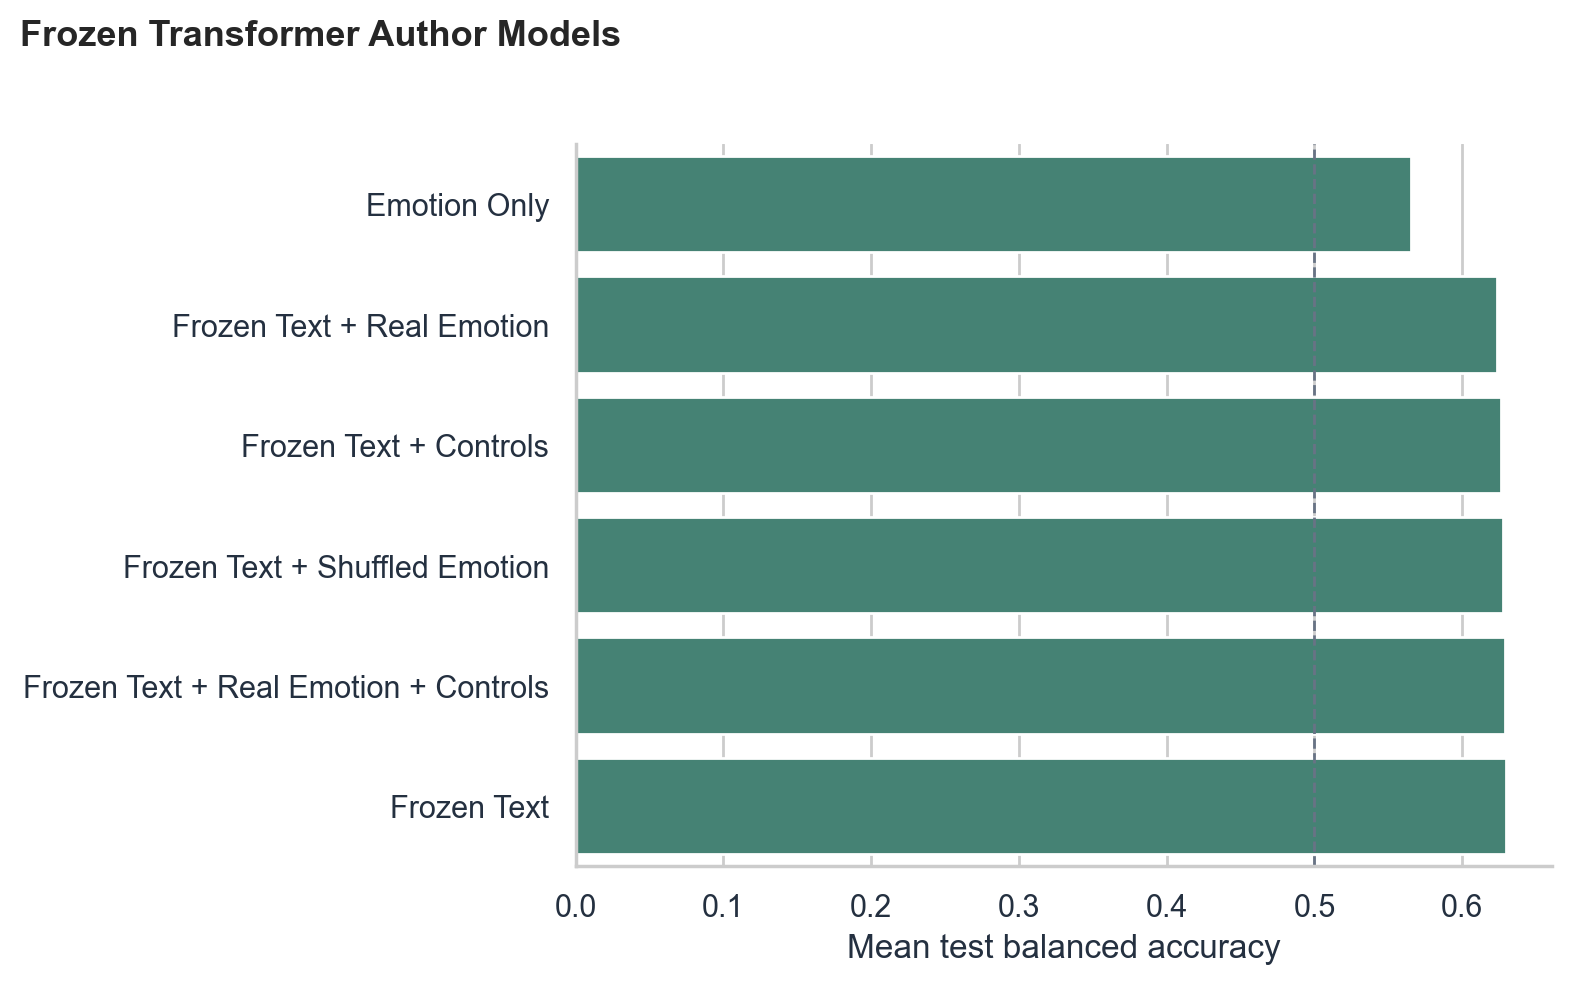

In [8]:
frozen_transformer_summary = pd.read_csv(REPORT_RESULTS_DIR / "frozen_transformer_model_summary.csv")
display(frozen_transformer_summary.style.format({
    "balanced_accuracy": "{:.4f}",
    "f1": "{:.4f}",
    "minority_recall": "{:.4f}",
    "roc_auc": "{:.4f}",
    "average_precision": "{:.4f}",
}))
show_png("fig_frozen_transformer_author_models.png")


Frozen MiniLM summaries are competitive with the corrected GRU models, but they do not beat TF-IDF. Averaging transformer embeddings is not enough; the model needs a better author-level aggregation mechanism.


## 10. Set/Attention Author Transformer Results

The set/attention model learns an author representation from a user's post embeddings without imposing a fake temporal order. We compare text-only, real emotion, shuffled emotion, controls, and post budgets of 50 versus 200 posts.


,model_id,model_name,balanced_accuracy,f1,minority_recall,roc_auc,average_precision,post_budget
0,set_attention_text_real_emotion_p200,Set Attention Text + Real Emotion p=200,0.6865,0.5064,0.6661,0.7515,0.5173,200
1,set_attention_text_p200,Set Attention Text p=200,0.6778,0.4989,0.6221,0.7433,0.4950,200
2,set_attention_text_shuffled_emotion_p200,Set Attention Text + Shuffled Emotion p=200,0.6752,0.5003,0.6846,0.7408,0.4983,200
3,set_attention_text_shuffled_emotion_p50,Set Attention Text + Shuffled Emotion p=50,0.6424,0.4559,0.6569,0.7024,0.4509,50
4,set_attention_text_p50,Set Attention Text p=50,0.6357,0.4519,0.6748,0.6957,0.4500,50
5,set_attention_text_real_emotion_controls_p200,Set Attention Text + Real Emotion + Controls p=200,0.6323,0.4358,0.6644,0.6829,0.4219,200
6,set_attention_text_controls_p200,Set Attention Text + Controls p=200,0.6290,0.4355,0.5634,0.6875,0.4240,200
7,set_attention_text_real_emotion_p50,Set Attention Text + Real Emotion p=50,0.6201,0.4269,0.5119,0.6941,0.4461,50
8,set_attention_text_real_emotion_controls_p50,Set Attention Text + Real Emotion + Controls p=50,0.6100,0.4315,0.5893,0.6515,0.3953,50
9,set_attention_text_controls_p50,Set Attention Text + Controls p=50,0.6069,0.4331,0.6001,0.6508,0.3928,50


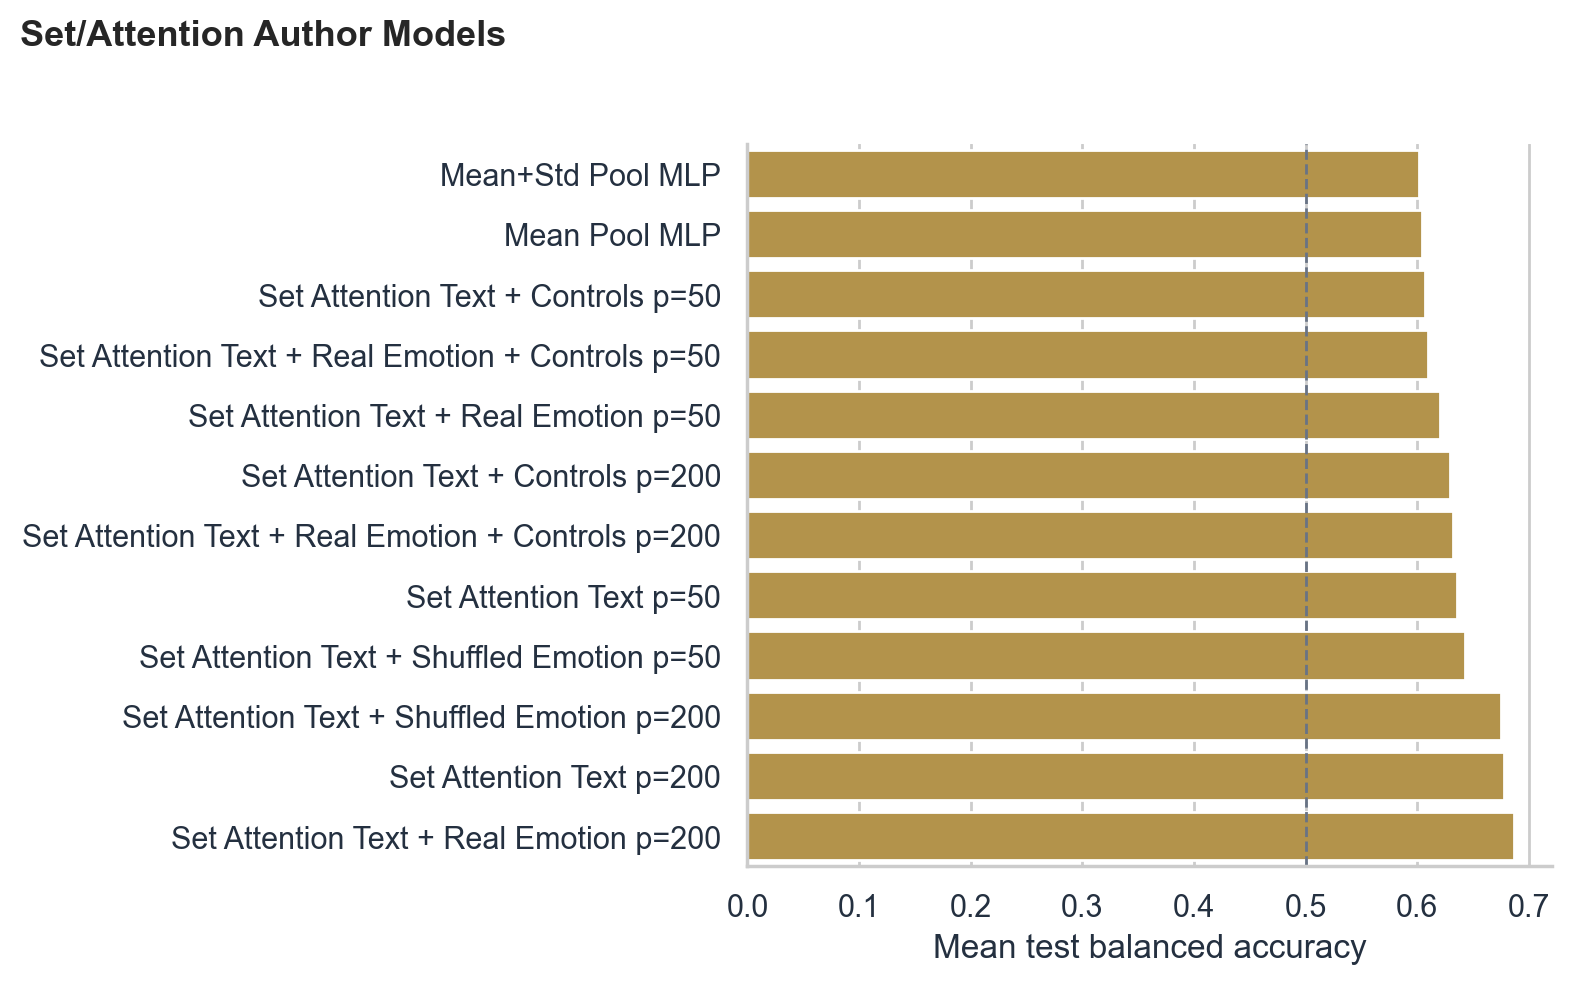

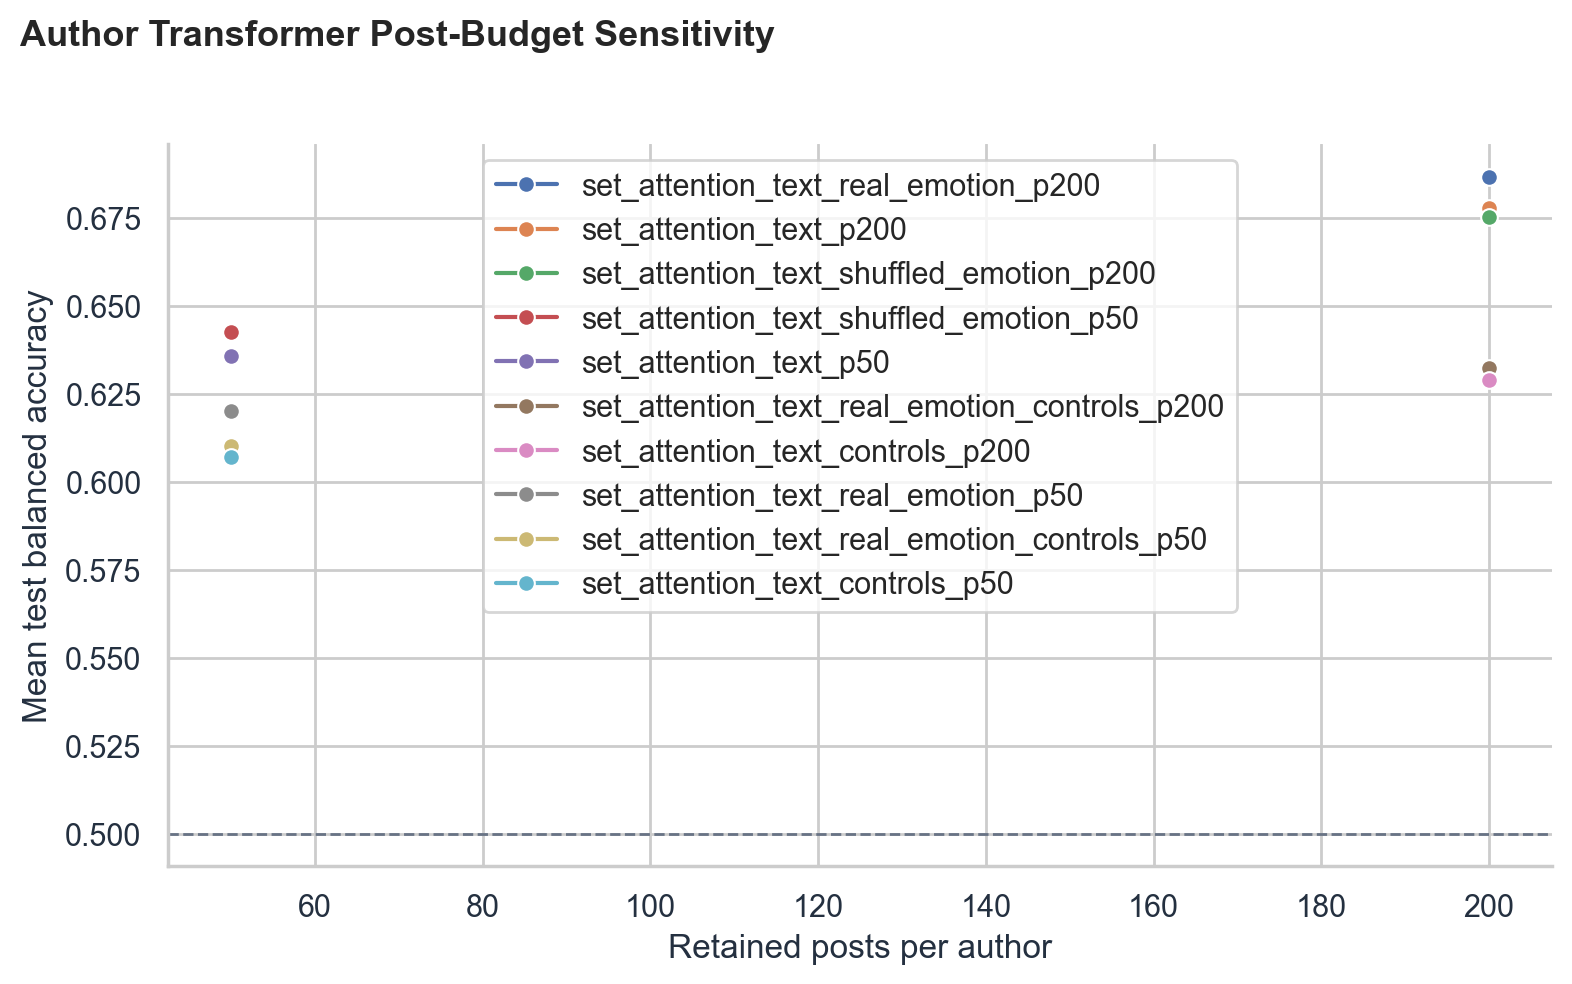

In [9]:
set_attention_summary = pd.read_csv(REPORT_RESULTS_DIR / "set_attention_model_summary.csv")
display(set_attention_summary.style.format({
    "balanced_accuracy": "{:.4f}",
    "f1": "{:.4f}",
    "minority_recall": "{:.4f}",
    "roc_auc": "{:.4f}",
    "average_precision": "{:.4f}",
    "post_budget": "{:.0f}",
}))
show_png("fig_set_attention_author_models.png")
show_png("fig_set_attention_post_budget.png")


The 200-post set/attention family is the strongest model family in the notebook. The post-budget comparison is central: using more author history improves performance substantially over the 50-post setting.


## 11. Does Emotion Add Signal Beyond Text?

The strict test is not whether an emotion model performs above chance. The strict test is whether **text + real emotion** beats the matched **text-only** model more than **text + shuffled emotion** does.


,comparison,metric,target,point_estimate,ci_lower,ci_upper,n_bootstrap,n_authors
4,Frozen transformer: real emotion minus text,balanced_accuracy,mean,-0.0060,-0.0155,+0.0029,2000,1563
9,Frozen transformer: shuffled emotion minus text,balanced_accuracy,mean,-0.0019,-0.0120,+0.0081,2000,1563
14,Set attention p=50: real emotion minus text,balanced_accuracy,mean,-0.0156,-0.0308,-0.0015,2000,1563
19,Set attention p=50: shuffled emotion minus text,balanced_accuracy,mean,+0.0067,-0.0050,+0.0187,2000,1563
24,Set attention p=200: real emotion minus text,balanced_accuracy,mean,+0.0087,-0.0041,+0.0223,2000,1563
29,Set attention p=200: shuffled emotion minus text,balanced_accuracy,mean,-0.0026,-0.0154,+0.0103,2000,1563


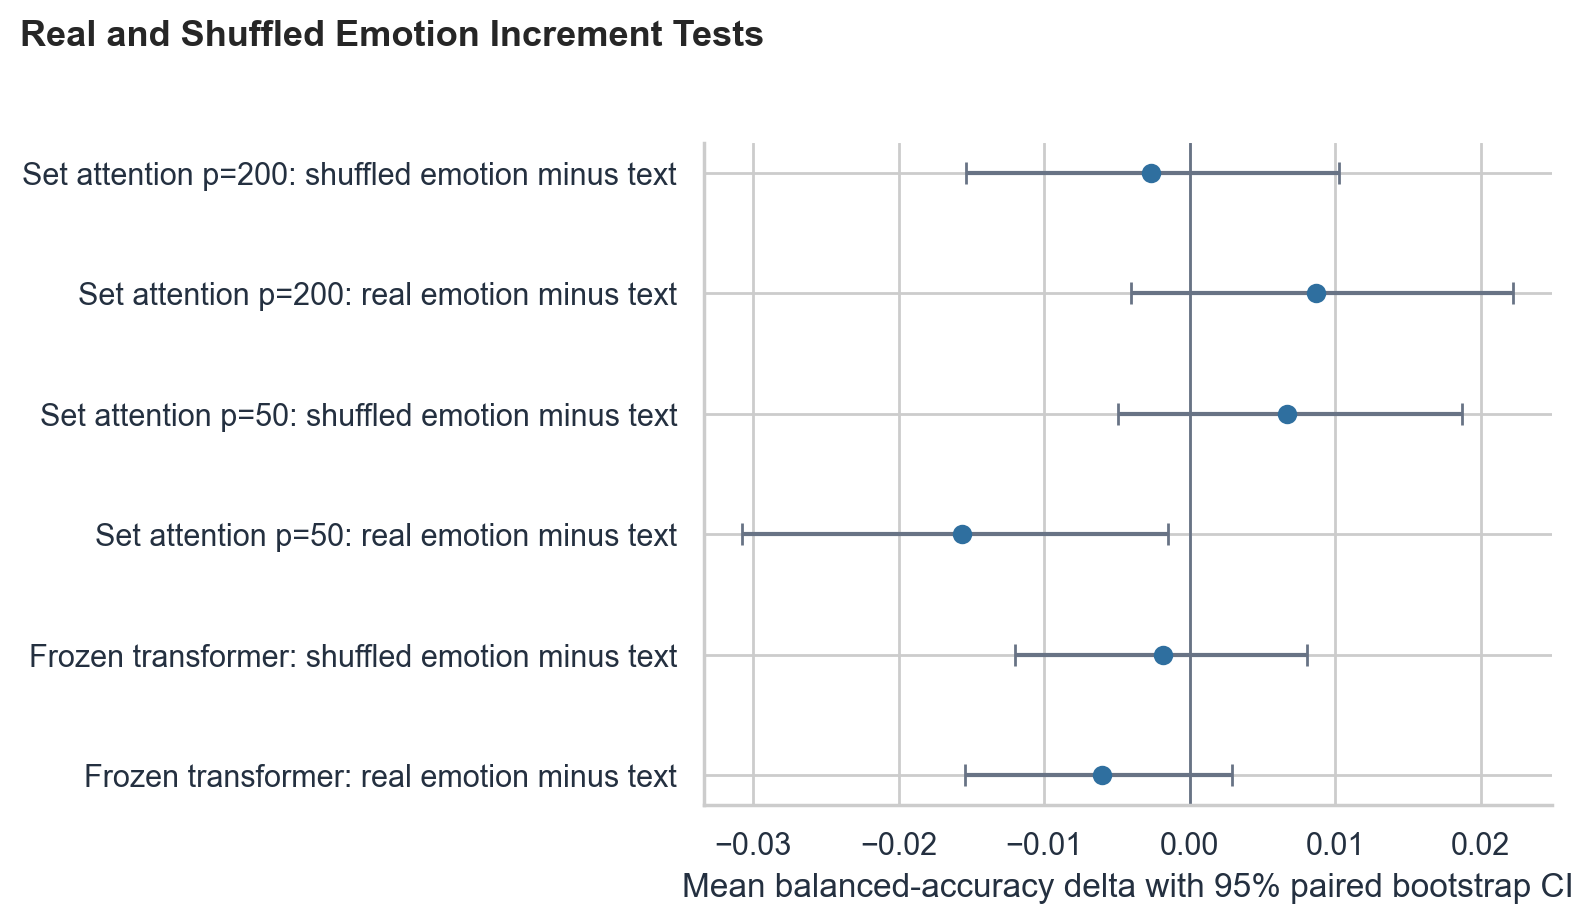

In [10]:
transformer_deltas = pd.read_csv(REPORT_RESULTS_DIR / "transformer_emotion_deltas.csv")
mean_deltas = transformer_deltas.loc[transformer_deltas["target"] == "mean"].copy()
display(mean_deltas.style.format({
    "point_estimate": "{:+.4f}",
    "ci_lower": "{:+.4f}",
    "ci_upper": "{:+.4f}",
}))
show_png("fig_transformer_emotion_deltas.png")


The headline p200 run gives a small positive real-emotion delta while shuffled emotion is slightly negative. That is suggestive, but the intervals and other model families are mixed, so the emotion claim should stay cautious.


## 12. Stability Checks for the Winning Family

Because the p200 set/attention result is the main model story, we ran two extra seeds and 10/20 epoch sensitivity for the three key p200 variants: text-only, real emotion, and shuffled emotion.


,model_id,model_name,post_budget,epochs,n_seeds,mean_balanced_accuracy,std_balanced_accuracy,min_balanced_accuracy,max_balanced_accuracy
0,set_attention_text_real_emotion_p200,Set Attention Text + Real Emotion p=200,200,5,3,0.6784,0.0101,0.6671,0.6865
1,set_attention_text_shuffled_emotion_p200,Set Attention Text + Shuffled Emotion p=200,200,5,3,0.6779,0.0034,0.6752,0.6818
2,set_attention_text_p200,Set Attention Text p=200,200,5,3,0.6761,0.0034,0.6723,0.6783


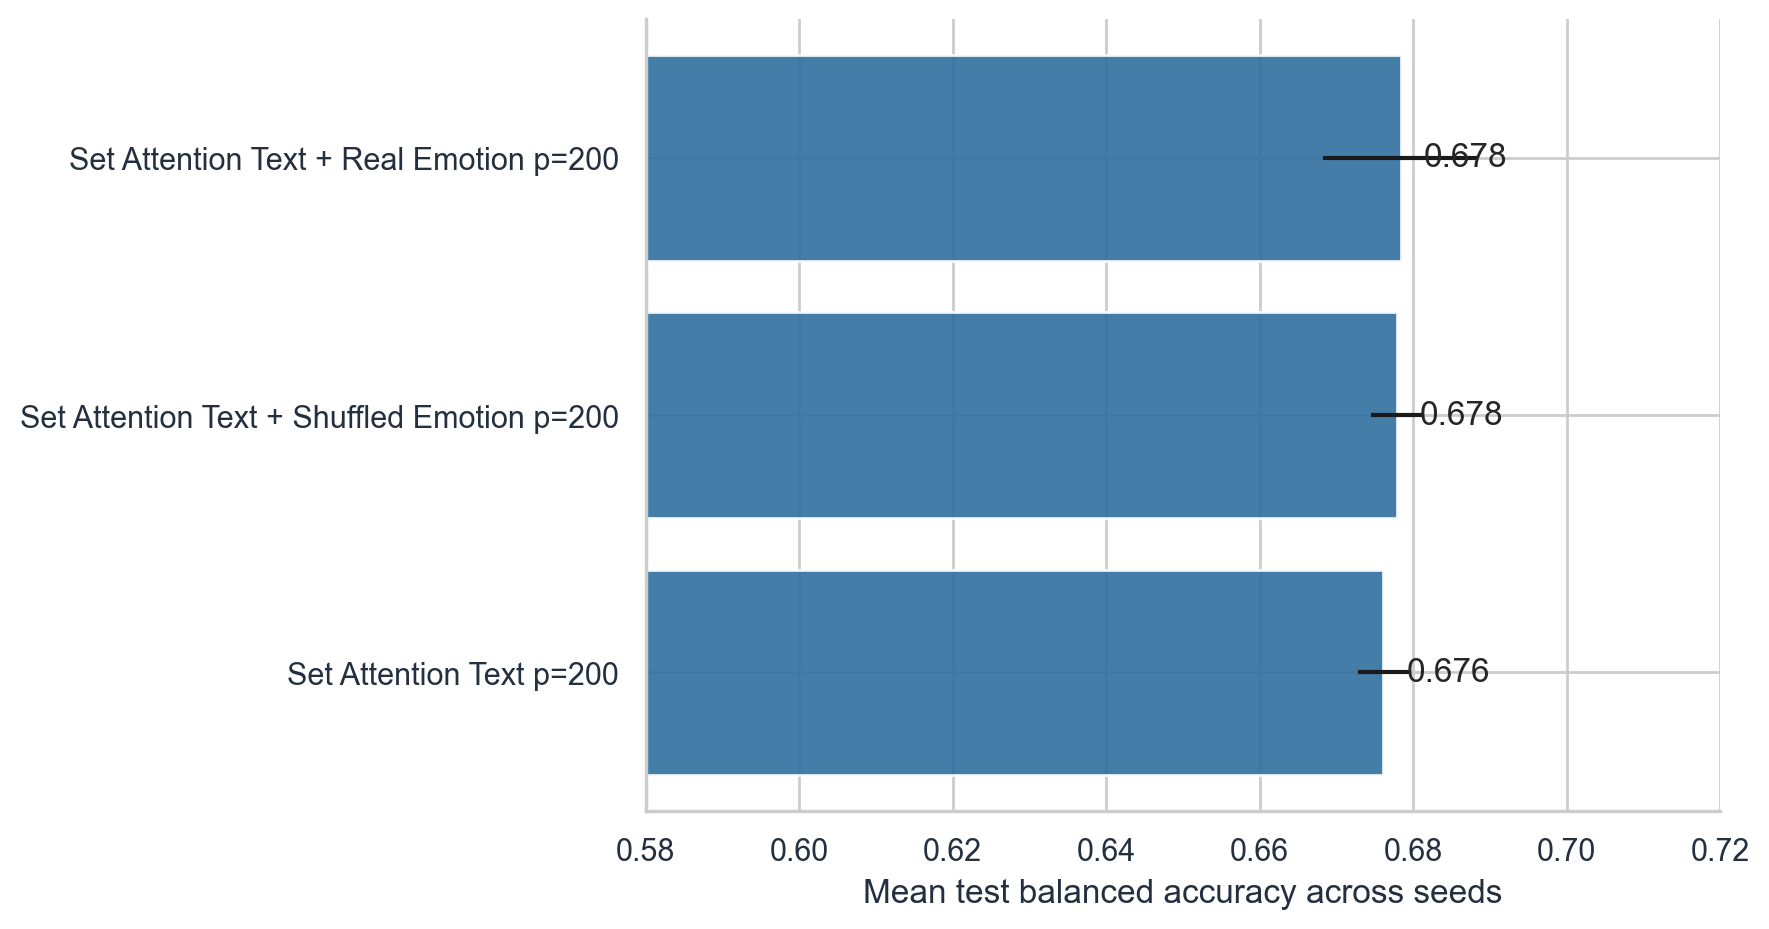

,analysis,run_id,seed,epochs,model_name,balanced_accuracy,f1,roc_auc
0,epoch_sensitivity,p200_e10_seed209066,209066,10,Set Attention Text + Shuffled Emotion p=200,0.6941,0.5149,0.7597
1,epoch_sensitivity,p200_e10_seed209066,209066,10,Set Attention Text + Real Emotion p=200,0.6883,0.4966,0.7534
2,epoch_sensitivity,p200_e10_seed209066,209066,10,Set Attention Text p=200,0.6849,0.4943,0.7550
3,epoch_sensitivity,p200_e20_seed209066,209066,20,Set Attention Text p=200,0.6888,0.5094,0.7530
4,epoch_sensitivity,p200_e20_seed209066,209066,20,Set Attention Text + Shuffled Emotion p=200,0.6817,0.4864,0.7502
5,epoch_sensitivity,p200_e20_seed209066,209066,20,Set Attention Text + Real Emotion p=200,0.6726,0.4820,0.7439
6,multi_seed,p200_e5_seed209067,209067,5,Set Attention Text + Shuffled Emotion p=200,0.6818,0.4953,0.7473
7,multi_seed,p200_e5_seed209067,209067,5,Set Attention Text + Real Emotion p=200,0.6816,0.4965,0.7488
8,multi_seed,p200_e5_seed209067,209067,5,Set Attention Text p=200,0.6723,0.4794,0.7398
9,multi_seed,p200_e5_seed209068,209068,5,Set Attention Text p=200,0.6783,0.4862,0.7477


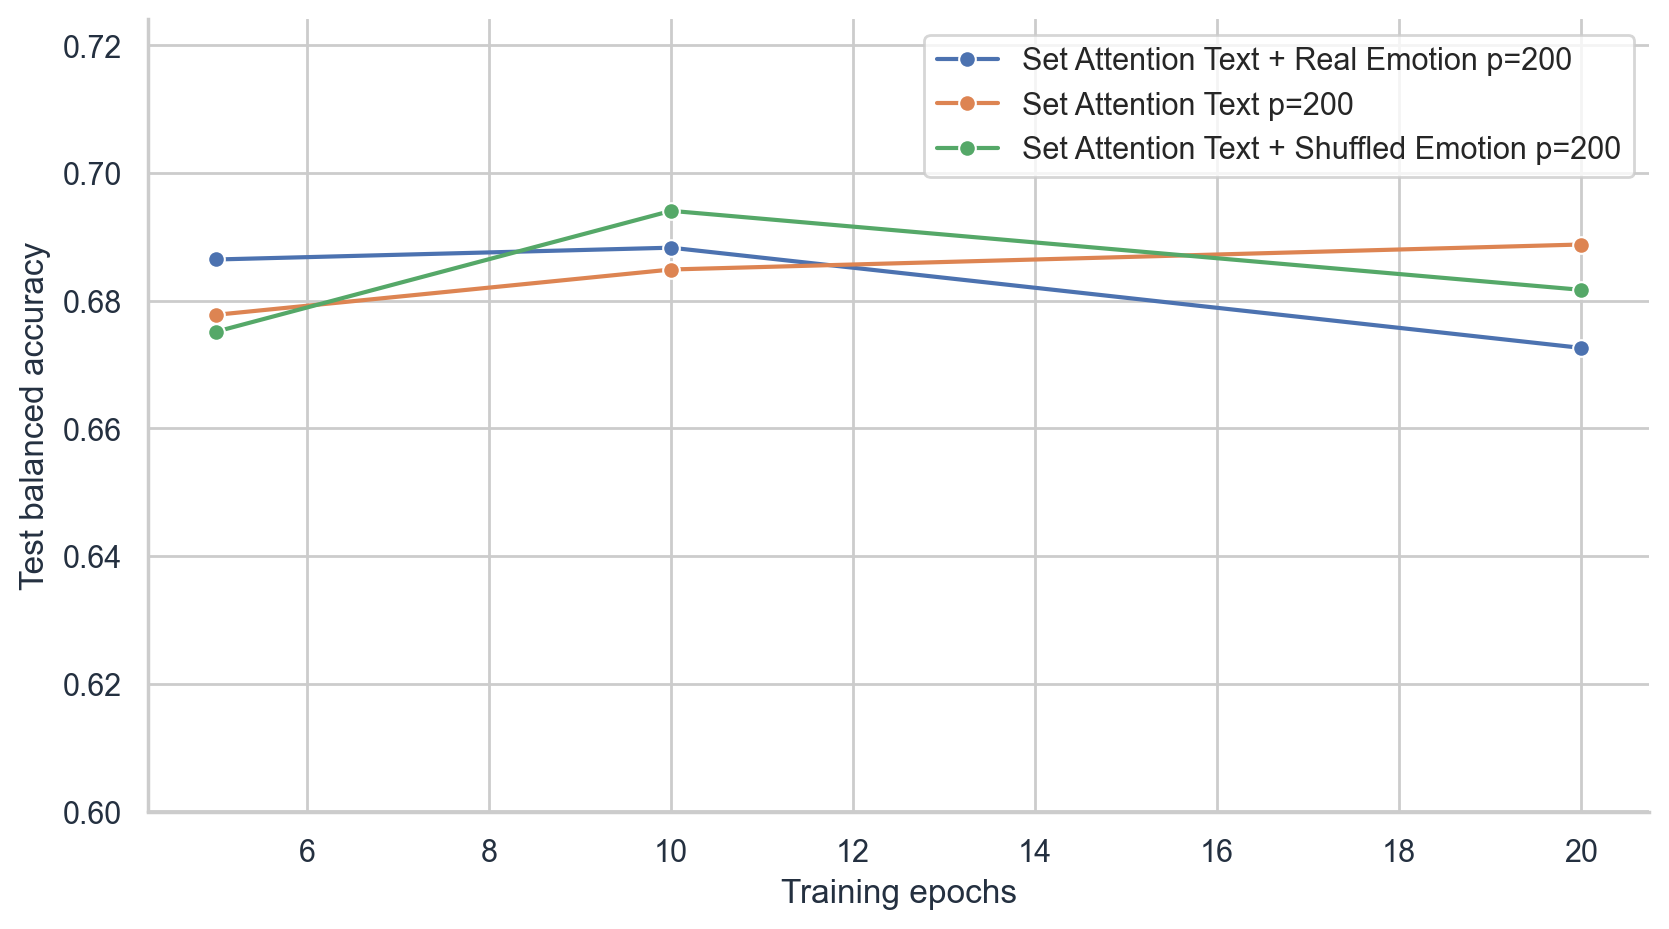

In [11]:
stability = pd.read_csv(REPORT_RESULTS_DIR / "set_attention_seed_stability.csv")
supplemental = pd.read_csv(REPORT_RESULTS_DIR / "set_attention_supplemental_summary.csv")

display(stability.style.format({
    "mean_balanced_accuracy": "{:.4f}",
    "std_balanced_accuracy": "{:.4f}",
    "min_balanced_accuracy": "{:.4f}",
    "max_balanced_accuracy": "{:.4f}",
}))
show_png("fig_set_attention_seed_stability.png")

compact_supplemental = supplemental[[
    "analysis", "run_id", "seed", "epochs", "model_name", "balanced_accuracy", "f1", "roc_auc"
]].copy()
display(compact_supplemental.style.format({
    "balanced_accuracy": "{:.4f}",
    "f1": "{:.4f}",
    "roc_auc": "{:.4f}",
}))
show_png("fig_set_attention_epoch_sensitivity.png")


The stability checks support the author-level set/attention direction, but they weaken a strong emotion-specific claim. Real emotion is competitive, yet shuffled emotion and text-only can match or exceed it under some seeds or training lengths.


## 13. Baseline Uncertainty and Thresholding

For the baseline layer, we also estimate bootstrap uncertainty and inspect threshold tuning. These diagnostics keep the evaluation honest under class imbalance.


,model_name,point_estimate,ci_lower,ci_upper,n_test_authors,n_bootstrap
2,TF-IDF Logistic,0.6512,0.6341,0.6673,1563,2000
8,GRU Text + Emotion,0.6223,0.6048,0.6398,1563,2000
4,GRU Text,0.5964,0.5802,0.6142,1563,2000
6,GRU Text Inverse Weight,0.5855,0.5689,0.6032,1563,2000
0,Majority,0.5000,0.5000,0.5000,1563,2000


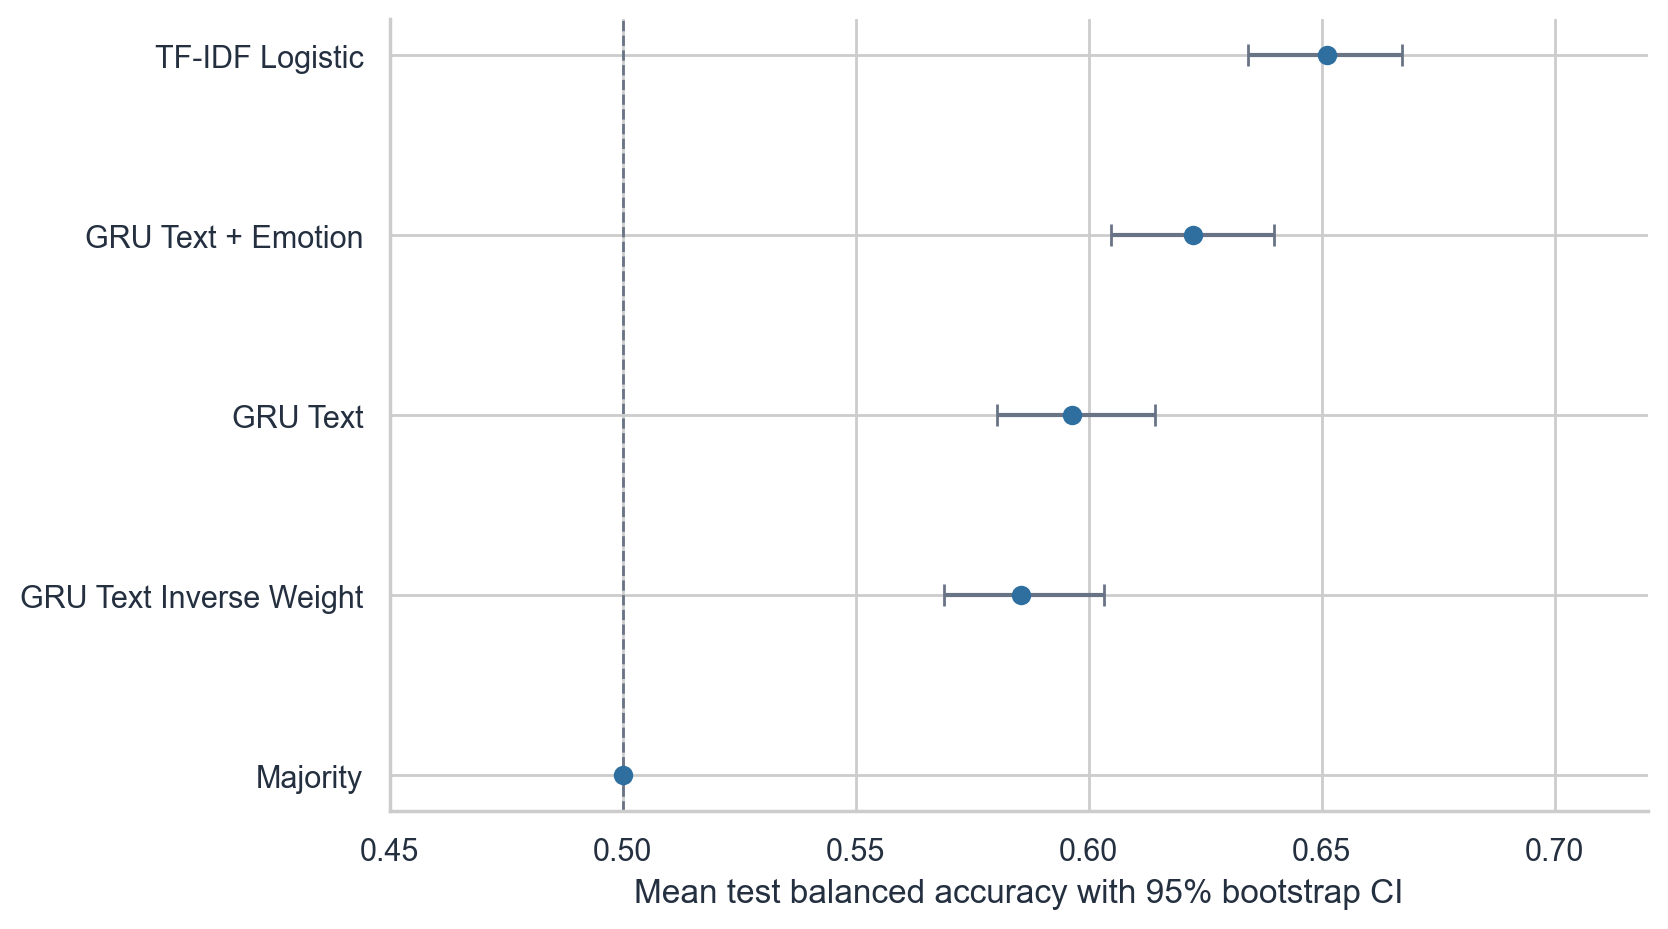

,target,threshold_objective,selected_threshold,validation_objective_score,test_balanced_accuracy,test_f1
0,target_E,balanced_accuracy,0.350,0.6466,0.6119,0.4004
1,target_E,f1,0.350,0.4388,0.6119,0.4004
2,target_S,balanced_accuracy,0.215,0.6117,0.5652,0.1485
3,target_S,f1,0.225,0.1951,0.5641,0.1688
4,target_T,balanced_accuracy,0.455,0.7047,0.6929,0.6369
5,target_T,f1,0.450,0.6570,0.6993,0.6520
6,target_J,balanced_accuracy,0.445,0.6158,0.6191,0.5484
7,target_J,f1,0.435,0.5970,0.5729,0.5900


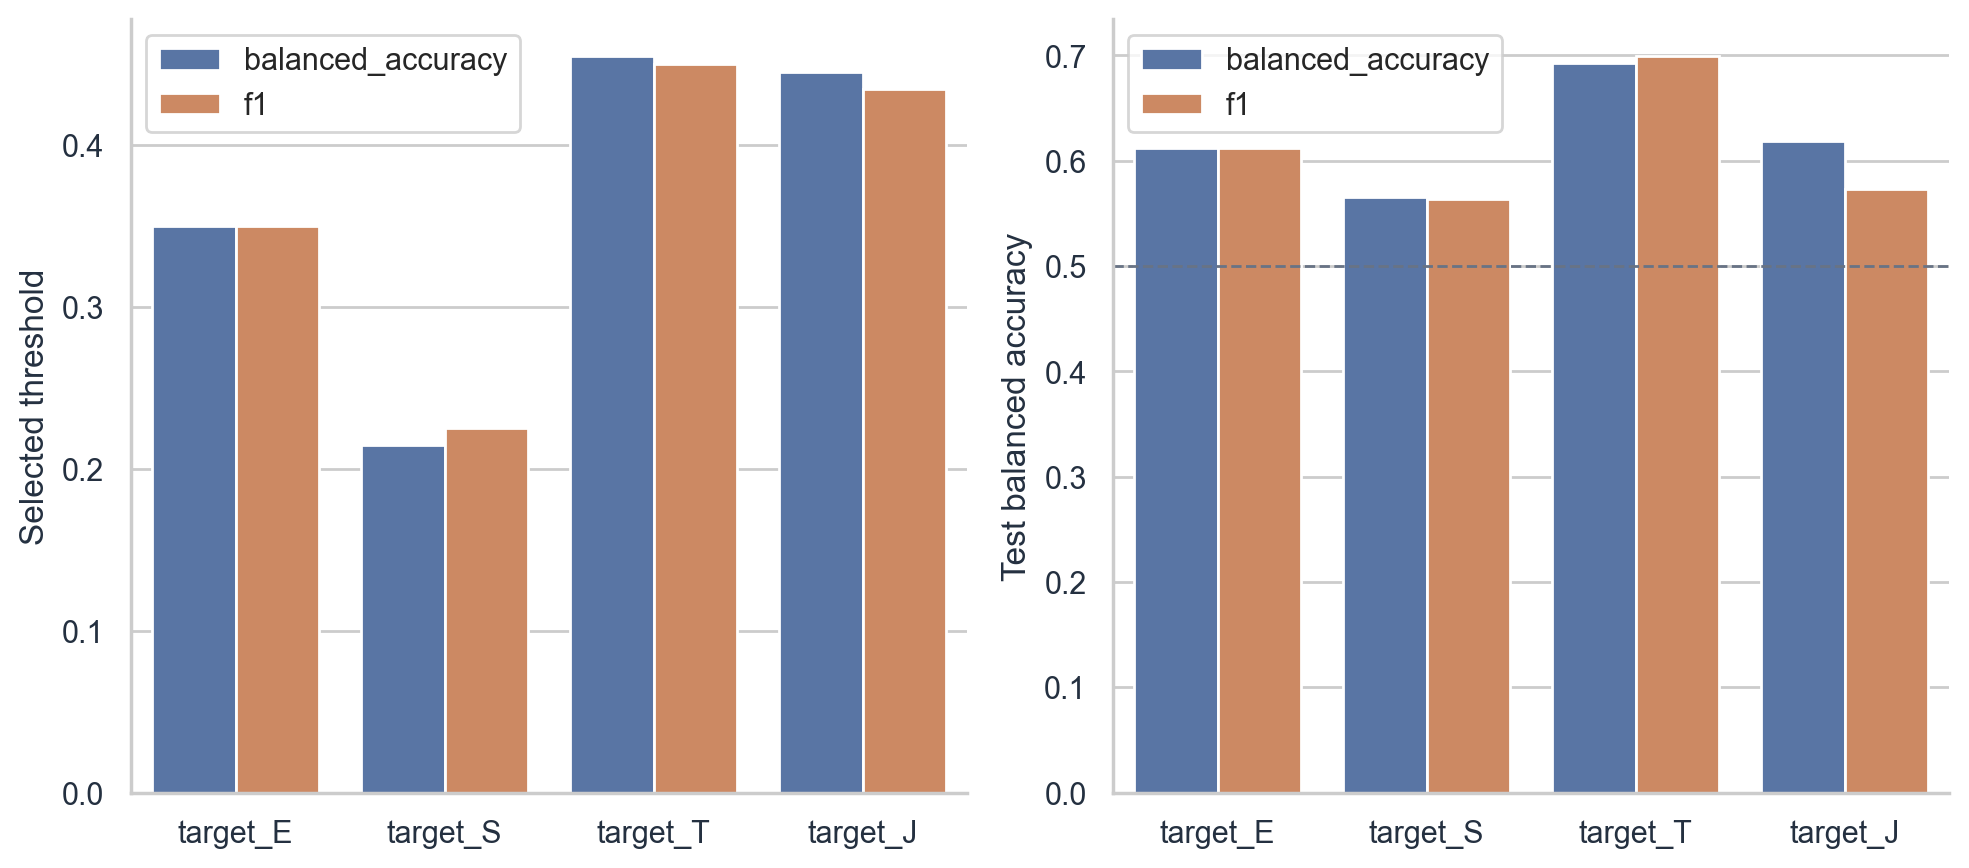

In [12]:
bootstrap_intervals = pd.read_csv(REPORT_RESULTS_DIR / "bootstrap_model_intervals.csv")
bootstrap_differences = pd.read_csv(REPORT_RESULTS_DIR / "bootstrap_pairwise_differences.csv")

balanced_accuracy_ci = bootstrap_intervals.loc[
    bootstrap_intervals["metric"] == "balanced_accuracy",
    ["model_name", "point_estimate", "ci_lower", "ci_upper", "n_test_authors", "n_bootstrap"],
].sort_values("point_estimate", ascending=False)

display(balanced_accuracy_ci.style.format({
    "point_estimate": "{:.4f}",
    "ci_lower": "{:.4f}",
    "ci_upper": "{:.4f}",
}))
show_png("fig_bootstrap_balanced_accuracy_ci.png")

threshold_sensitivity = pd.read_csv(REPORT_RESULTS_DIR / "threshold_objective_sensitivity.csv")
display(threshold_sensitivity.style.format({
    "selected_threshold": "{:.3f}",
    "validation_objective_score": "{:.4f}",
    "test_balanced_accuracy": "{:.4f}",
    "test_f1": "{:.4f}",
}))
show_png("fig_threshold_objective_sensitivity.png")


These diagnostics explain the evaluation choices. Validation-tuned thresholds and balanced accuracy are needed because class imbalance can make raw accuracy misleading, and the bootstrap intervals discourage overinterpreting small model differences.


## 14. Final Takeaways

The final story is not that one feature magically solves MBTI prediction. The stronger and more defensible story is that the model has to match the unit of the label.

The best current evidence supports **author-level set/attention modeling**: represent each user by a set of posts, use enough author history, and evaluate only on held-out authors. The p200 set/attention family is the strongest model family in the notebook, outperforming TF-IDF, frozen MiniLM summary probes, and corrected GRU baselines.

The emotion result is more cautious. Real emotion features are competitive and sometimes improve over text-only, but the seed and epoch checks show that shuffled emotion and text-only can match or exceed real emotion under some settings. The final report should frame emotion-derived features as a suggestive secondary signal, not as a robust standalone driver of performance.

The main methodological contribution is therefore the author-level formulation with scientific controls: author-level splits, validation-tuned thresholds, shuffled-emotion negative controls, and test-only paired deltas.


## Reproducibility Notes

- Data source: Reddit MBTI dataset loaded through KaggleHub, with MBTI leakage masking before modeling.
- Emotion features: DistilBERT-style emotion probabilities applied to Reddit posts and treated as text-derived transferred representations.
- Main metric: author-level mean balanced accuracy over `E/I`, `N/S`, `F/T`, and `J/P` dimensions.
- Submission path: this notebook loads compact CSV/PNG artifacts from `report/results/`; large local caches and checkpoints are intentionally excluded from git.
- Excluded mainline experiment: supervised post-level transformer fine-tuning, because it changes the estimand and reintroduces noisy post-level MBTI labels.
